Column Names:
['complaint_id', 'citizen_name', 'location', 'complaint_text', 'department', 'priority', 'status', 'date_reported']

Original Dataset:
{'complaint_id': '1001', 'citizen_name': 'Ravi Kumar', 'location': 'Hyderabad', 'complaint_text': 'No water supply in our street for 2 days', 'department': 'Water', 'priority': 'High', 'status': 'Pending', 'date_reported': '2026-04-11'}
{'complaint_id': '1002', 'citizen_name': 'Priya Sharma', 'location': 'Vijayawada', 'complaint_text': 'Street lights are not working near school', 'department': 'Electricity', 'priority': 'Medium', 'status': 'Pending', 'date_reported': '2026-04-11'}
{'complaint_id': '1003', 'citizen_name': 'Arjun Reddy', 'location': 'Warangal', 'complaint_text': 'Road is damaged and causing traffic', 'department': 'Roads', 'priority': 'High', 'status': 'In Progress', 'date_reported': '2026-04-10'}
{'complaint_id': '1004', 'citizen_name': 'Sneha Rao', 'location': 'Guntur', 'complaint_text': 'Garbage not collected for 3 days',

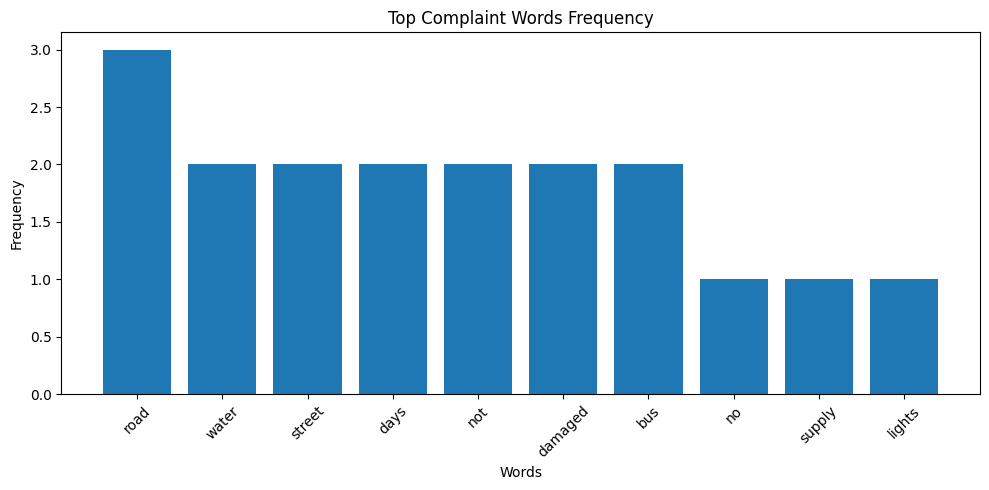

In [7]:
import csv
import re
from collections import Counter
import matplotlib.pyplot as plt

# Read CSV file
data = []
with open("../data/complaints.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    print("Column Names:")
    print(reader.fieldnames)

    for row in reader:
        data.append(row)

print("\nOriginal Dataset:")
for row in data:
    print(row)

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    stop_words = [
        "is", "the", "in", "our", "for", "and",
        "of", "to", "a", "are", "on", "near"
    ]

    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]

    return " ".join(cleaned_words)

# Apply cleaning safely
for row in data:
    complaint = row.get("complaint_text", "")
    row["cleaned_text"] = clean_text(complaint)

print("\nCleaned Dataset:")
for row in data:
    print(row)

# Word frequency analysis
all_words = []
for row in data:
    all_words.extend(row["cleaned_text"].split())

word_freq = Counter(all_words)

top_words = word_freq.most_common(10)

print("\nTop 10 Frequent Words:")
print(top_words)

# Plot frequency graph
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top Complaint Words Frequency")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()